<a href="https://colab.research.google.com/github/Oluwapelumi-E/Oluwapelumi-E-Data-cleaning-and-Visualization/blob/main/HPRACTICAL5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import Timestamp
import warnings
import plotly.graph_objects as go
import plotly.offline as pyo
import plotly.io as pio
import sklearn
import plotly.express as ex
warnings.filterwarnings('ignore')

This cell imports important Python libraries needed for data manipulation. Libraries like NumPy and Pandas help in handling and analyzing data, while Matplotlib, Seaborn, and Plotly are used for creating charts and visualizations. Scikit-learn supports machine learning tasks, and the Timestamp function helps manage date and time data. The warnings library is also used to hide unnecessary warning messages and keep the output clean and readable.

In [2]:
data=pd.read_csv('/content/supermart sales.csv')

This cell load the  CSV file into Python using Pandas. The dataset named “supermart sales.csv” is read and stored in a variable called data as a DataFrame .

In [3]:
data

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu
...,...,...,...,...,...,...,...,...,...,...,...
9989,OD9990,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10,Tamil Nadu
9990,OD9991,Alan,Bakery,Biscuits,Kanyakumari,07-12-2015,West,1195,0.26,71.70,Tamil Nadu
9991,OD9992,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44,Tamil Nadu
9992,OD9993,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24,Tamil Nadu


This cell displays the data we load and explain its dimensions (rows, columns), showing that it initially had 9994 rows and 11 columns.




In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


This cell helps in summarizing the dataset. It shows important information in the dataset i.e. the number of rows and columns, the names of each column, the data type of each column, and the number of non-null (non-missing) values. In which we have 2 float 1 integer and 8 object as the datatype and no empty (nan value) in the dataset


In [5]:
data.nunique()

,0
Order ID,9994
Customer Name,50
Category,7
Sub Category,23
City,24
Order Date,1236
Region,5
Sales,1989
Discount,26
Profit,8380


This cell helps in finding the number of unique values in each column of the dataset. It helps to show how many different entries exist in every feature. For Example Order_ID has 9994 row that shows that the number are just numerically counted in our data and also the state just has 1 state.

In [6]:
data = data.drop(['Order ID', "State"], axis=1)

Drop is used to remove a data that you dont need in the dataset. The columns “Order ID” and “State” are dropped because they are not needed for the analysis. And also the axis=1 tells Python to remove columns (not rows)

In [7]:
data

,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit
0,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28
1,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80
2,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20
3,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60
4,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45
...,...,...,...,...,...,...,...,...,...
9989,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10
9990,Alan,Bakery,Biscuits,Kanyakumari,07-12-2015,West,1195,0.26,71.70
9991,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44
9992,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24


This cell (data) is load to check if the Order_Id and State we drop earlier has drooped in our dataset

> Add blockquote



In [8]:
data['Category'].unique()

array(['Oil & Masala', 'Beverages', 'Food Grains', 'Fruits & Veggies',
       'Bakery', 'Snacks', 'Eggs, Meat & Fish'], dtype=object)

This cell display all the unique values in the 'Category' column of the dataset. This shows the product category in an array form and also show if there are Outliers in the product category.It helps to show the different types of product categories available without repetition.




In [9]:
data['Order Date'].unique()

array(['11-08-2017', '06-12-2017', '10-11-2016', ..., '3/16/2015',
       '8/29/2016', '04-06-2017'], dtype=object)

This cell display all the unique values in the 'Order_Date' column of the dataset. This shows the Order_Date  in an array form. It also show how the date is written and helps to know if the date are in the same format. In this column we have both hyphen(-) and forward slash(/) which is not a standard date format in python  

In [10]:
data.columns = data.columns.str.replace(' ', '_') # Replacing the space(s) in the colunm names with underscore(_)
data


,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit
0,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28
1,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80
2,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20
3,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60
4,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45
...,...,...,...,...,...,...,...,...,...
9989,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10
9990,Alan,Bakery,Biscuits,Kanyakumari,07-12-2015,West,1195,0.26,71.70
9991,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44
9992,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24


This code is used to replace spaces in the column names with underscores (_) to make the column names easier to access and work in order to afford unnecessary error and also helps in improving the code readability. And also load the data to display the updated dataset with the new column names.

In [11]:
searchfor = ['/']
data[data.Order_Date.str.contains('|'.join(searchfor))]

,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit
12,Sharon,Snacks,Cookies,Dindigul,4/15/2018,South,1659,0.19,315.21
14,Sundar,"Eggs, Meat & Fish",Chicken,Kanyakumari,11/22/2016,Central,831,0.22,207.75
15,Ramesh,Oil & Masala,Edible Oil & Ghee,Krishnagiri,11/22/2016,Central,1440,0.11,100.80
17,Arutra,Beverages,Health Drinks,Bodi,5/13/2015,West,1617,0.19,113.19
18,Haseena,"Eggs, Meat & Fish",Mutton,Tenkasi,8/27/2015,West,1757,0.35,386.54
...,...,...,...,...,...,...,...,...,...
9985,Shree,"Eggs, Meat & Fish",Mutton,Kanyakumari,11/13/2016,West,1286,0.30,475.82
9987,Ganesh,Fruits & Veggies,Fresh Vegetables,Theni,10/19/2015,West,1350,0.15,67.50
9989,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10
9992,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24


This cell search for rows in the Order_Date column that contain the symbol (/)

In [12]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], format='mixed')

data['Order_Date'] = data['Order_Date'].dt.strftime('%d-%m-%Y')

print(data)

     Customer_Name           Category      Sub_Category         City  \
0           Harish       Oil & Masala           Masalas      Vellore   
1            Sudha          Beverages     Health Drinks  Krishnagiri   
2          Hussain        Food Grains      Atta & Flour   Perambalur   
3          Jackson   Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4          Ridhesh        Food Grains   Organic Staples         Ooty   
...            ...                ...               ...          ...   
9989        Sudeep  Eggs, Meat & Fish              Eggs      Madurai   
9990          Alan             Bakery          Biscuits  Kanyakumari   
9991          Ravi        Food Grains              Rice         Bodi   
9992          Peer       Oil & Masala            Spices   Pudukottai   
9993        Ganesh        Food Grains      Atta & Flour  Tirunelveli   

      Order_Date Region  Sales  Discount  Profit  
0     08-11-2017  North   1254      0.12  401.28  
1     08-11-2017  South    749   

This code is used to convert the Order_Date column into a proper date format using Pandas. The to_datetime() function helps Python recognize different date formats correctly. After conversion, the dates are reformatted into the day-month-year (dd-mm-yyyy) format using strftime(). And after that the updated dataset is displayed using print(data).

In [13]:
data['Order_Date'].unique()

array(['08-11-2017', '12-06-2017', '11-10-2016', ..., '16-03-2015',
       '29-08-2016', '06-04-2017'], dtype=object)

Loading the cell to confirm the uniqueness of the Order_date after the convertion  of the date format changing in which python converted the date to an acceptable python format

In [14]:
#Converting a timestamp colunm into string so we can extract 'Year as Yr', 'Month as Mth', 'Date as Dy'

df=data['Order_Date'].astype(str)

#extract 'Year as Yr', 'Month as Mth', 'Date as Dy'

data['Dy'] = df.apply(lambda x: x.split("-")[0])
data['Mth'] = df.apply(lambda x: x.split("-")[1])
data['Yr'] = df.apply(lambda x: x.split("-")[2])

#print our new data
data

,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit,Dy,Mth,Yr
0,Harish,Oil & Masala,Masalas,Vellore,08-11-2017,North,1254,0.12,401.28,08,11,2017
1,Sudha,Beverages,Health Drinks,Krishnagiri,08-11-2017,South,749,0.18,149.80,08,11,2017
2,Hussain,Food Grains,Atta & Flour,Perambalur,12-06-2017,West,2360,0.21,165.20,12,06,2017
3,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,11-10-2016,South,896,0.25,89.60,11,10,2016
4,Ridhesh,Food Grains,Organic Staples,Ooty,11-10-2016,South,2355,0.26,918.45,11,10,2016
...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,24-12-2015,West,945,0.16,359.10,24,12,2015
9990,Alan,Bakery,Biscuits,Kanyakumari,12-07-2015,West,1195,0.26,71.70,12,07,2015
9991,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44,06,06,2017
9992,Peer,Oil & Masala,Spices,Pudukottai,16-10-2018,West,1659,0.15,597.24,16,10,2018


The date values are converted to string format so they can be separated easily. And then extract the day, month, and year from the Order_Date column, Using the split() function, the code divides each date into three parts based on the hyphen (-) and creates new columns named Dy (Day), Mth (Month), and Yr (Year). And later load the data for confirmation



In [15]:
data = data.drop(['Order_Date'],axis=1)

Dropping the Order_Date after extracting the day month and year from it

In [16]:
data

,Customer_Name,Category,Sub_Category,City,Region,Sales,Discount,Profit,Dy,Mth,Yr
0,Harish,Oil & Masala,Masalas,Vellore,North,1254,0.12,401.28,08,11,2017
1,Sudha,Beverages,Health Drinks,Krishnagiri,South,749,0.18,149.80,08,11,2017
2,Hussain,Food Grains,Atta & Flour,Perambalur,West,2360,0.21,165.20,12,06,2017
3,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,South,896,0.25,89.60,11,10,2016
4,Ridhesh,Food Grains,Organic Staples,Ooty,South,2355,0.26,918.45,11,10,2016
...,...,...,...,...,...,...,...,...,...,...,...
9989,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,West,945,0.16,359.10,24,12,2015
9990,Alan,Bakery,Biscuits,Kanyakumari,West,1195,0.26,71.70,12,07,2015
9991,Ravi,Food Grains,Rice,Bodi,West,1567,0.16,501.44,06,06,2017
9992,Peer,Oil & Masala,Spices,Pudukottai,West,1659,0.15,597.24,16,10,2018


Loading the dataset for confirmation of the operation

In [17]:
data[['Dy', 'Mth', 'Yr']] =data[['Dy', 'Mth', 'Yr']].astype(int)

The date values are converted to integer  format

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_Name  9994 non-null   object 
 1   Category       9994 non-null   object 
 2   Sub_Category   9994 non-null   object 
 3   City           9994 non-null   object 
 4   Region         9994 non-null   object 
 5   Sales          9994 non-null   int64  
 6   Discount       9994 non-null   float64
 7   Profit         9994 non-null   float64
 8   Dy             9994 non-null   int64  
 9   Mth            9994 non-null   int64  
 10  Yr             9994 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 859.0+ KB


Checking for any error before proceeding to the EDA (EXPLORATORY DATA ANALYSIS)by using info() function


In [19]:
cat_cols=data.select_dtypes(include=['object']).columns

num_cols = data.select_dtypes(include=np.number).columns.tolist()

print("Categorical Variables:")

print(cat_cols)

print("Numerical Variables:")

print(num_cols)



Categorical Variables:
Index(['Customer_Name', 'Category', 'Sub_Category', 'City', 'Region'], dtype='object')
Numerical Variables:
['Sales', 'Discount', 'Profit', 'Dy', 'Mth', 'Yr']


This cell separate the dataset columns into categorical and numerical variables based on their data types. Columns containing text values are identified as categorical variables, while columns containing numbers are identified as numerical variables.

In [20]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00


This cell installs the ydata-profiling library for generating comprehensive exploratory data analysis reports.

In [21]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 15.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

This cell generate an automated data profiling report for the dataset using the ydata_profiling library. The ProfileReport() function analyzes the dataset and provides a detailed summary, including statistics, missing values, data types, distributions, and relationships between variables.

# **EDA (EXPLORATORY DATA ANALYSIS)**

**Univariate Analysis**

Sales
Skew : 0.0


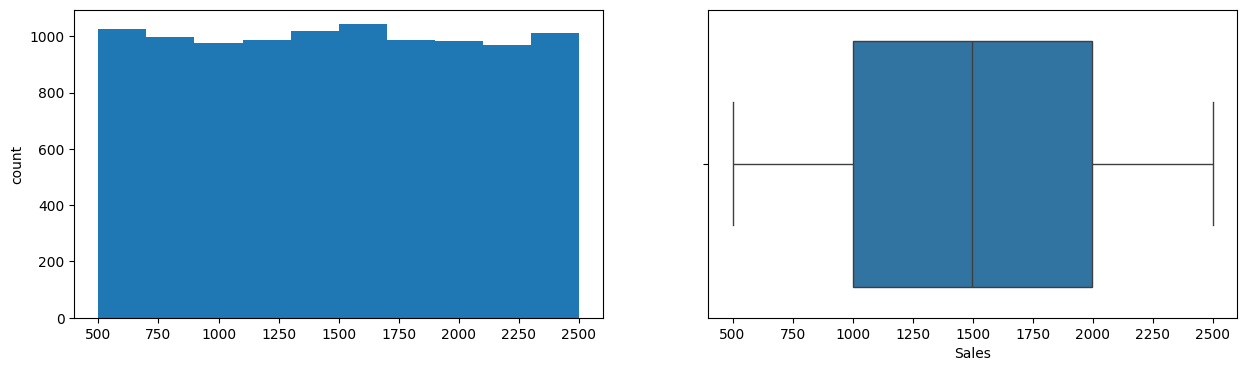

Discount
Skew : -0.03


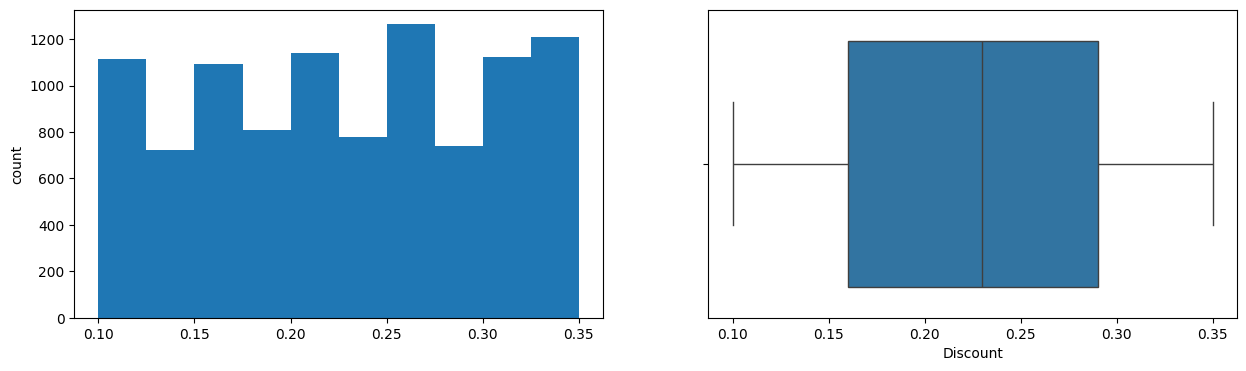

Profit
Skew : 0.77


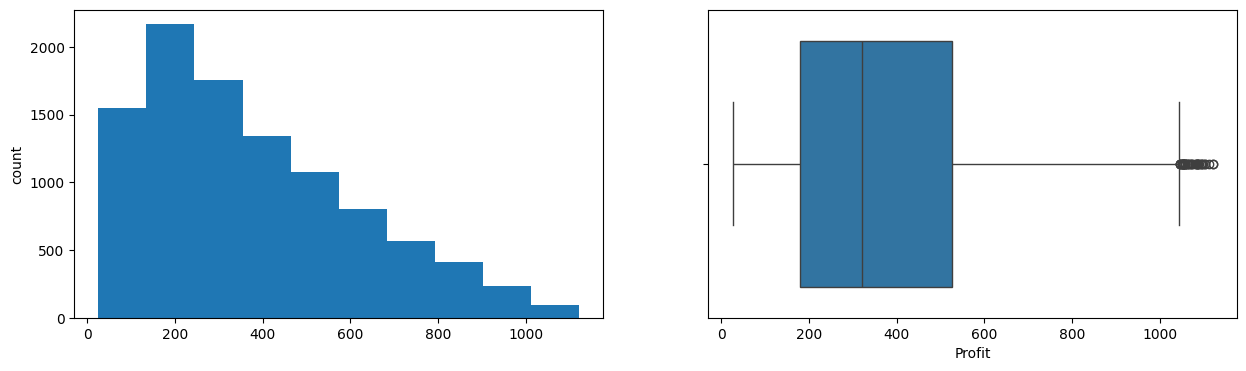

Dy
Skew : 0.02


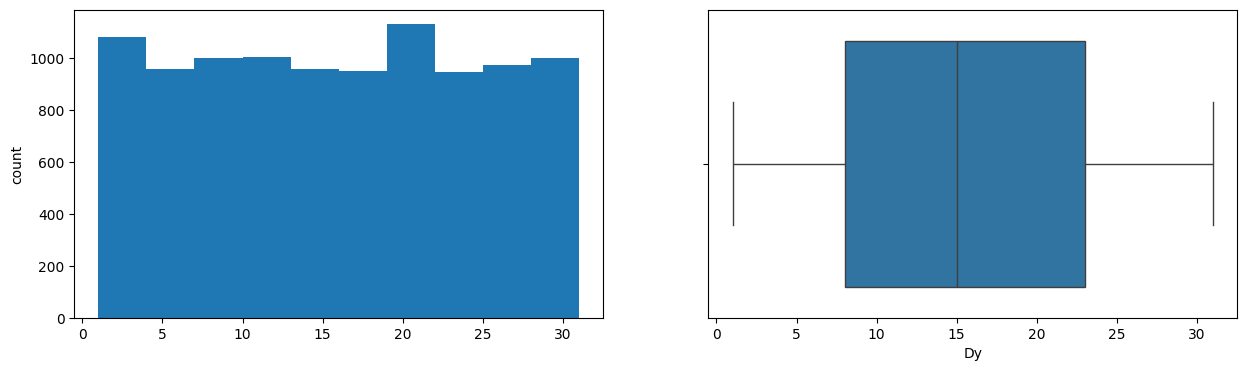

Mth
Skew : -0.43


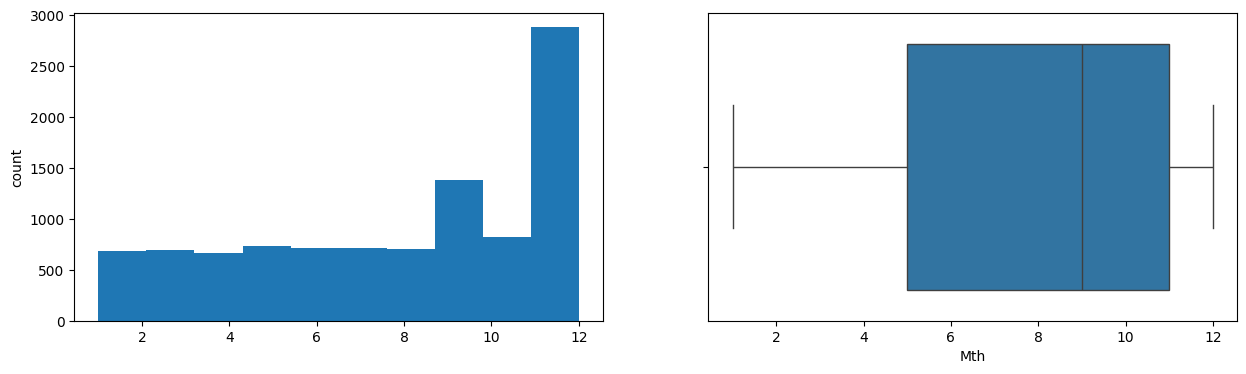

Yr
Skew : -0.28


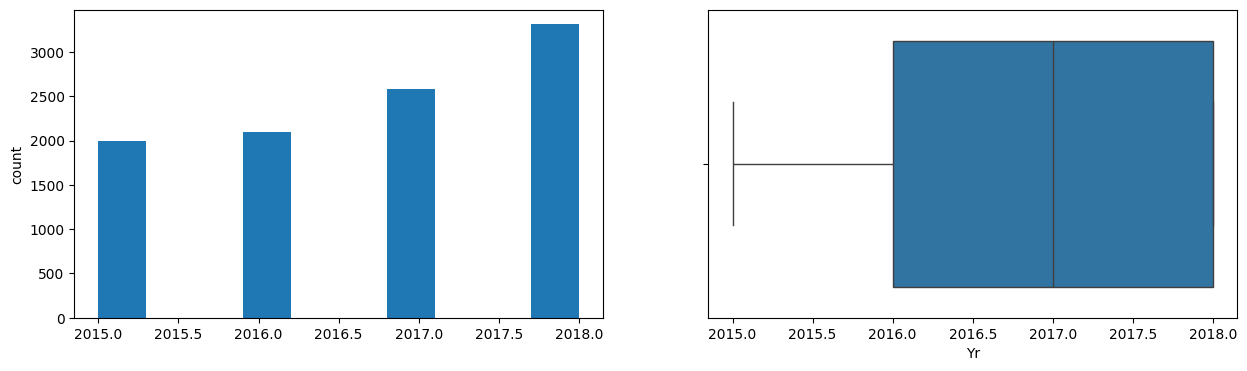

In [22]:
# checking for skewness and outliers in our numeric variable

for col in num_cols:
    print(col)
    print('Skew :', round(data[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    data[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])
    plt.show()

This cell analyze and visualize all the numerical columns in the dataset. In this cell the sales(0.0) has a normal distribution feequency, Discount(-0.03) data is balanced and does not contain significant extreme value , Profit(0.77) has a Positive distribution i.e most profit values are concentrated on the lower side, Dy(0.02) indicates that the data is almost perfectly symmetrical. i.e.dy values are evenly distributed with little skewness, Mth(-0.43)indicates a negative skew i.e.the month values are fairly balanced but slightly concentrated toward the higher end of the distribution, Yr(-0.28)indicates a slight negative skew

# **UNIVARIATE ANALYSIS**

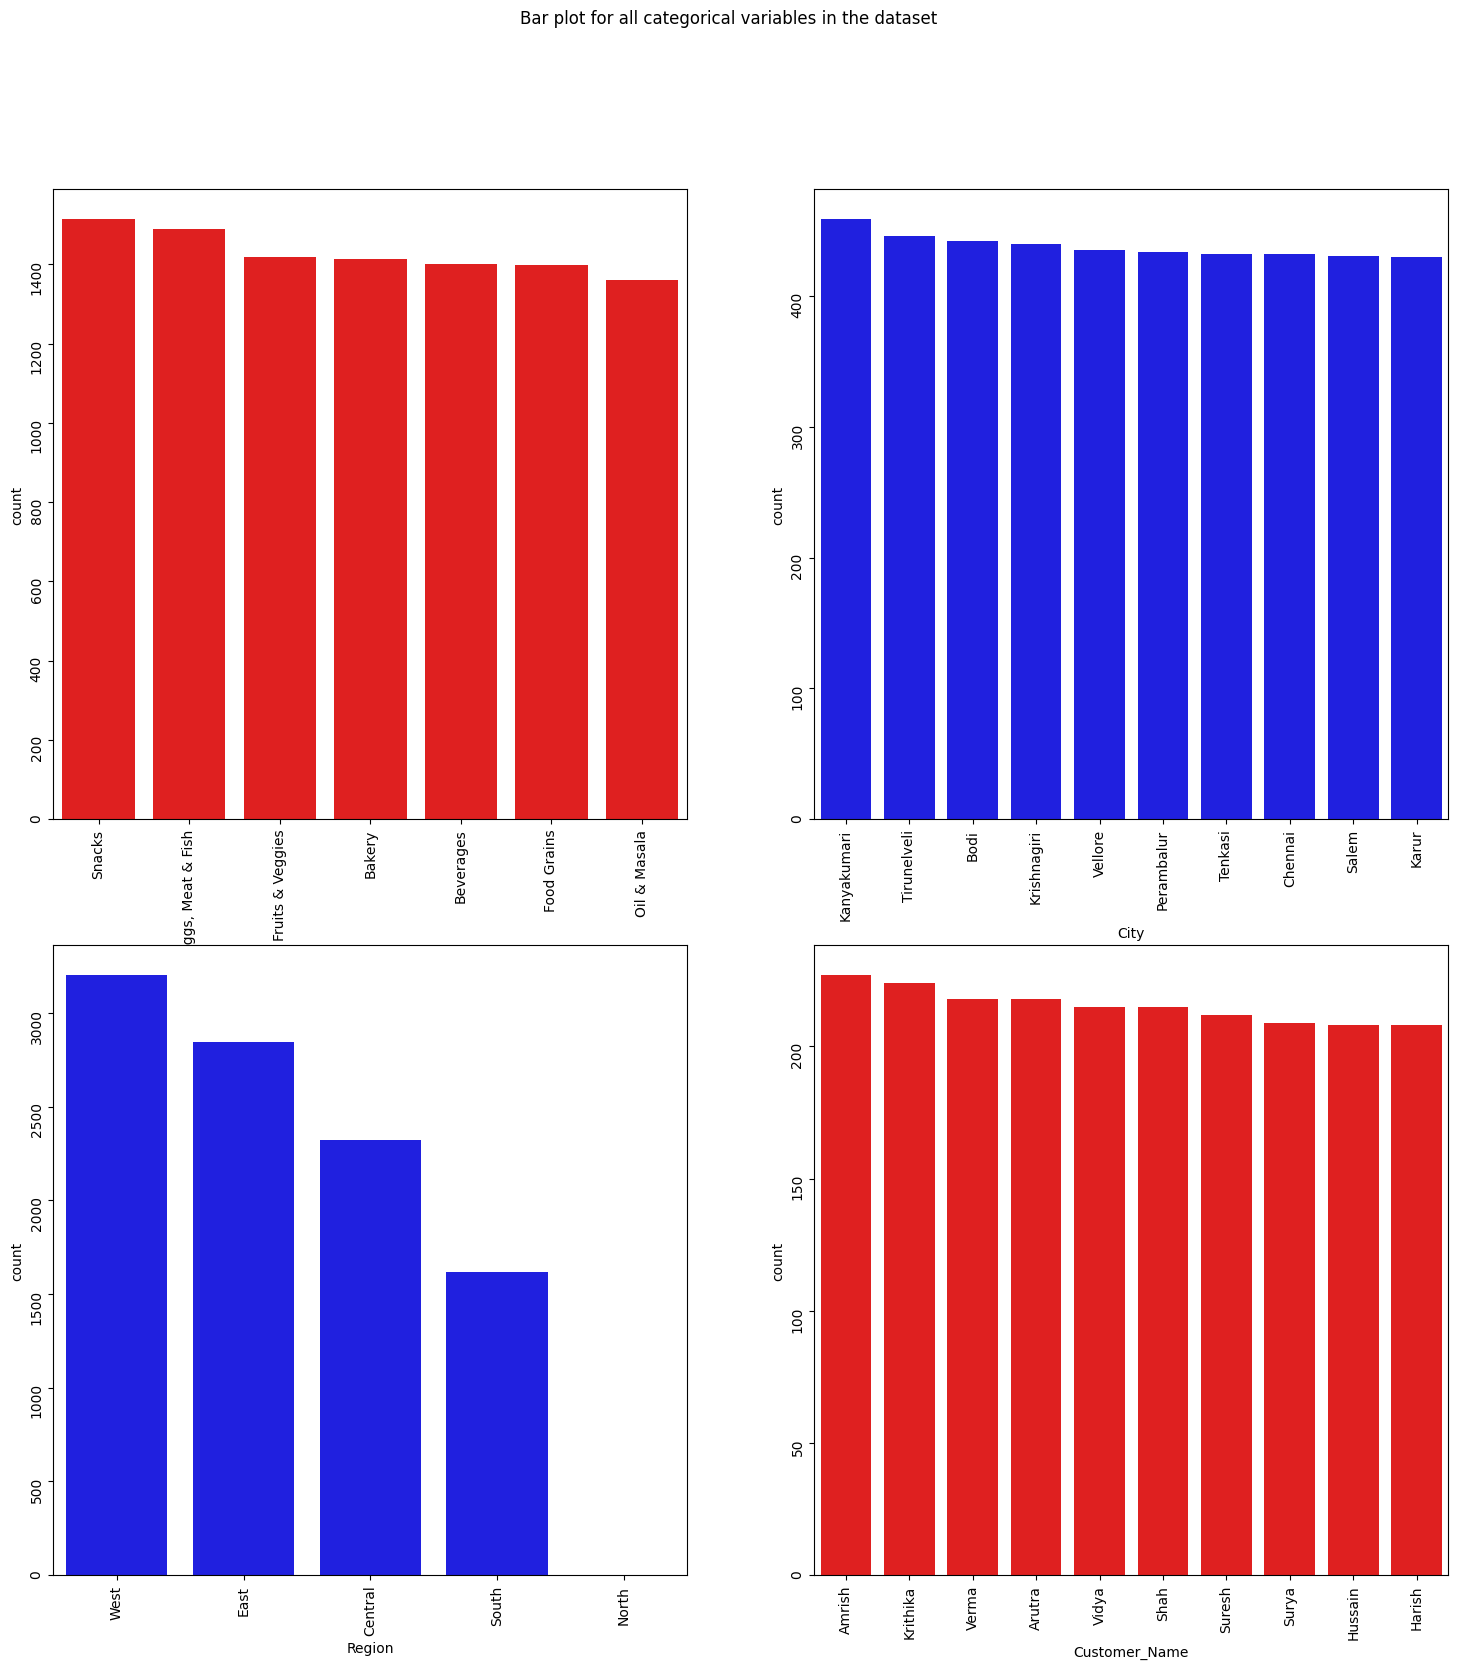

In [23]:
fig, axes = plt.subplots(2, 2, figsize = (18, 18))
fig.suptitle('Bar plot for all categorical variables in the dataset')


sns.countplot(ax = axes[0, 0], x = 'Category', data = data, color = 'red',
              order = data['Category'].value_counts().head(10).index);
sns.countplot(ax = axes[0, 1], x = 'City', data = data, color = 'blue',
              order = data['City'].value_counts().head(10).index);
sns.countplot(ax = axes[1, 0], x = 'Region', data = data, color = 'blue',
              order = data['Region'].value_counts().head(10).index);
sns.countplot(ax = axes[1, 1], x = 'Customer_Name', data = data, color = 'red',
              order = data['Customer_Name'].value_counts().head(10).index);
axes[0][0].tick_params(labelrotation=90);
axes[0][1].tick_params(labelrotation=90);
axes[1][0].tick_params(labelrotation=90);
axes[1] [1].tick_params(labelrotation=90);


This cell create multiple bar charts for the categorical variables in the dataset using Seaborn and Matplotlib. A 2x2 subplot layout is created to display count plots for Category, City, Region, and Customer_Name.And also the countplot() function is used to show the frequency of the top 10 most common values in each category. Different colors are added to improve visualization, while tick_params(labelrotation=90) rotates the axis labels to make them easier to read.

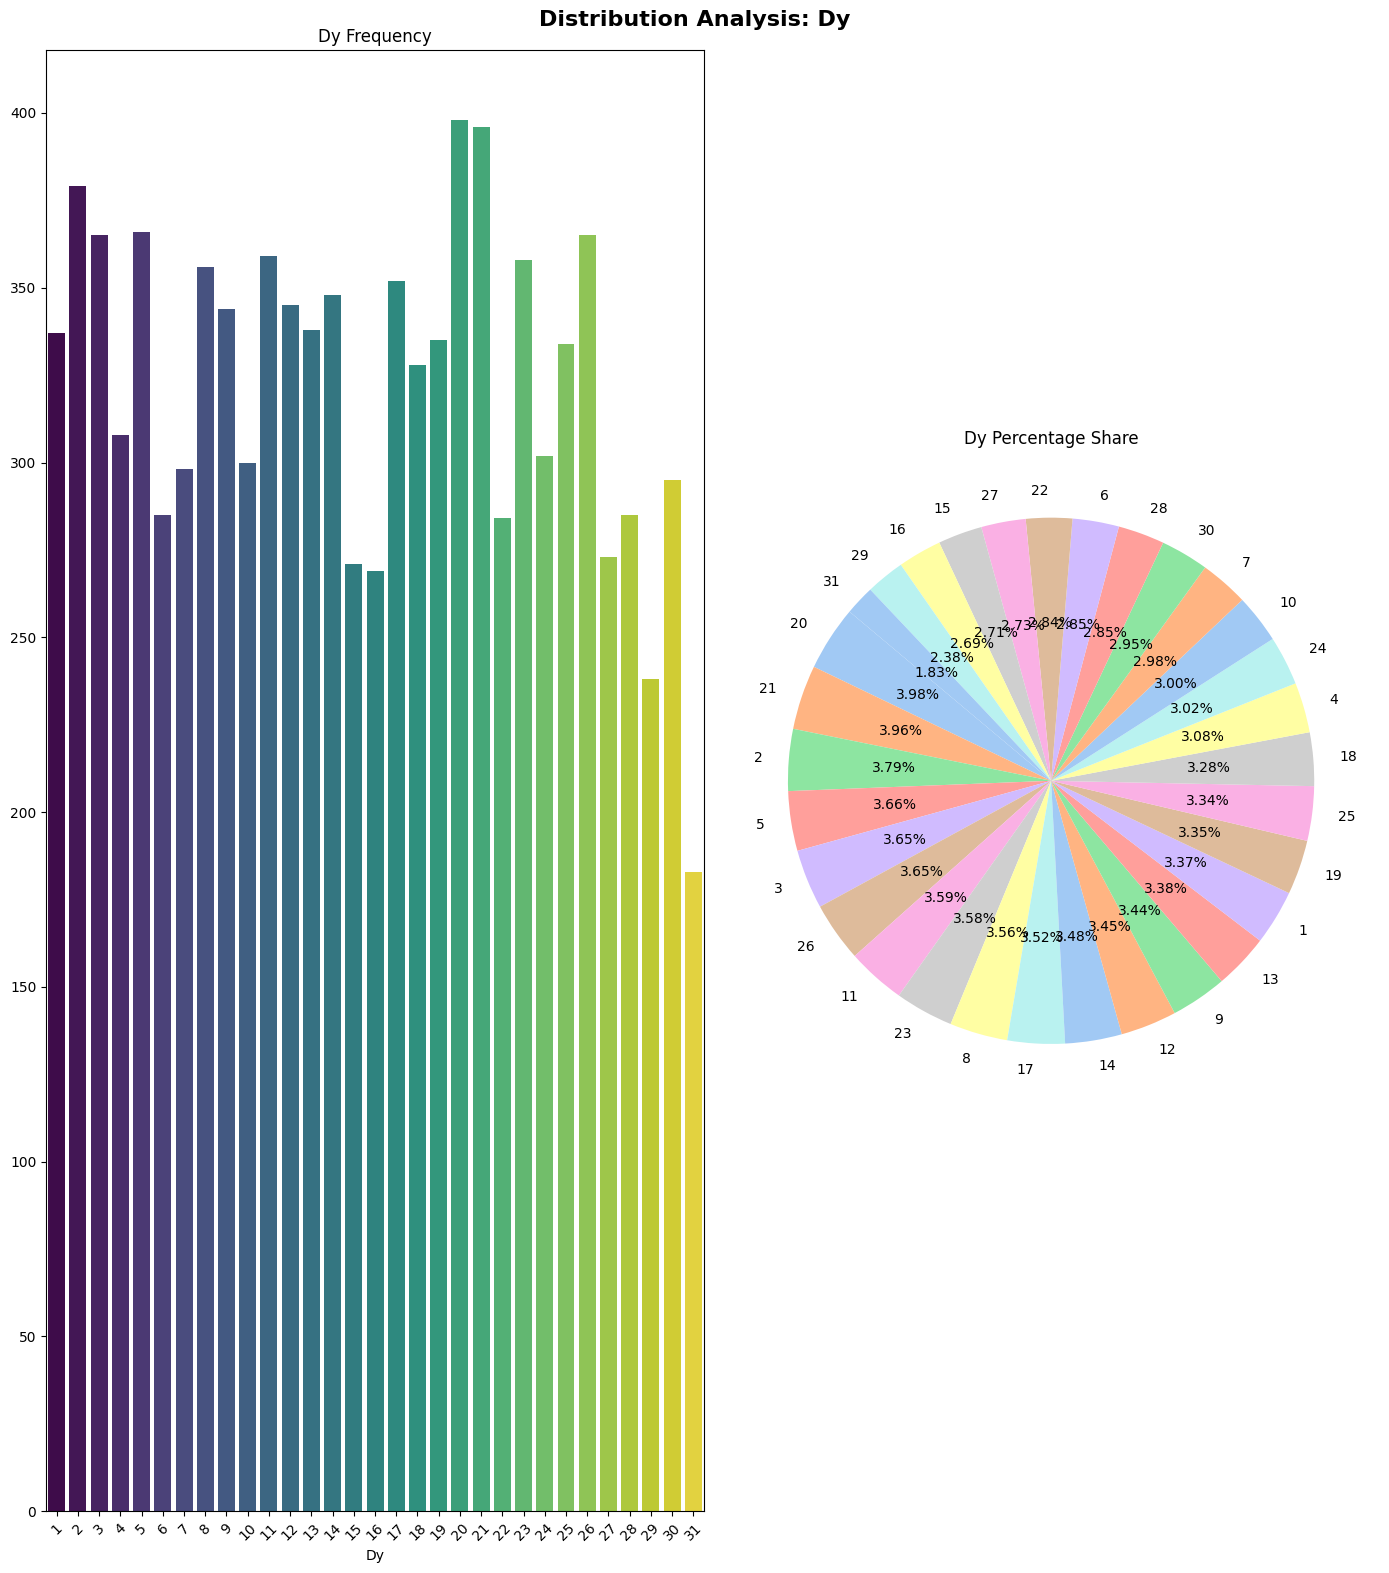

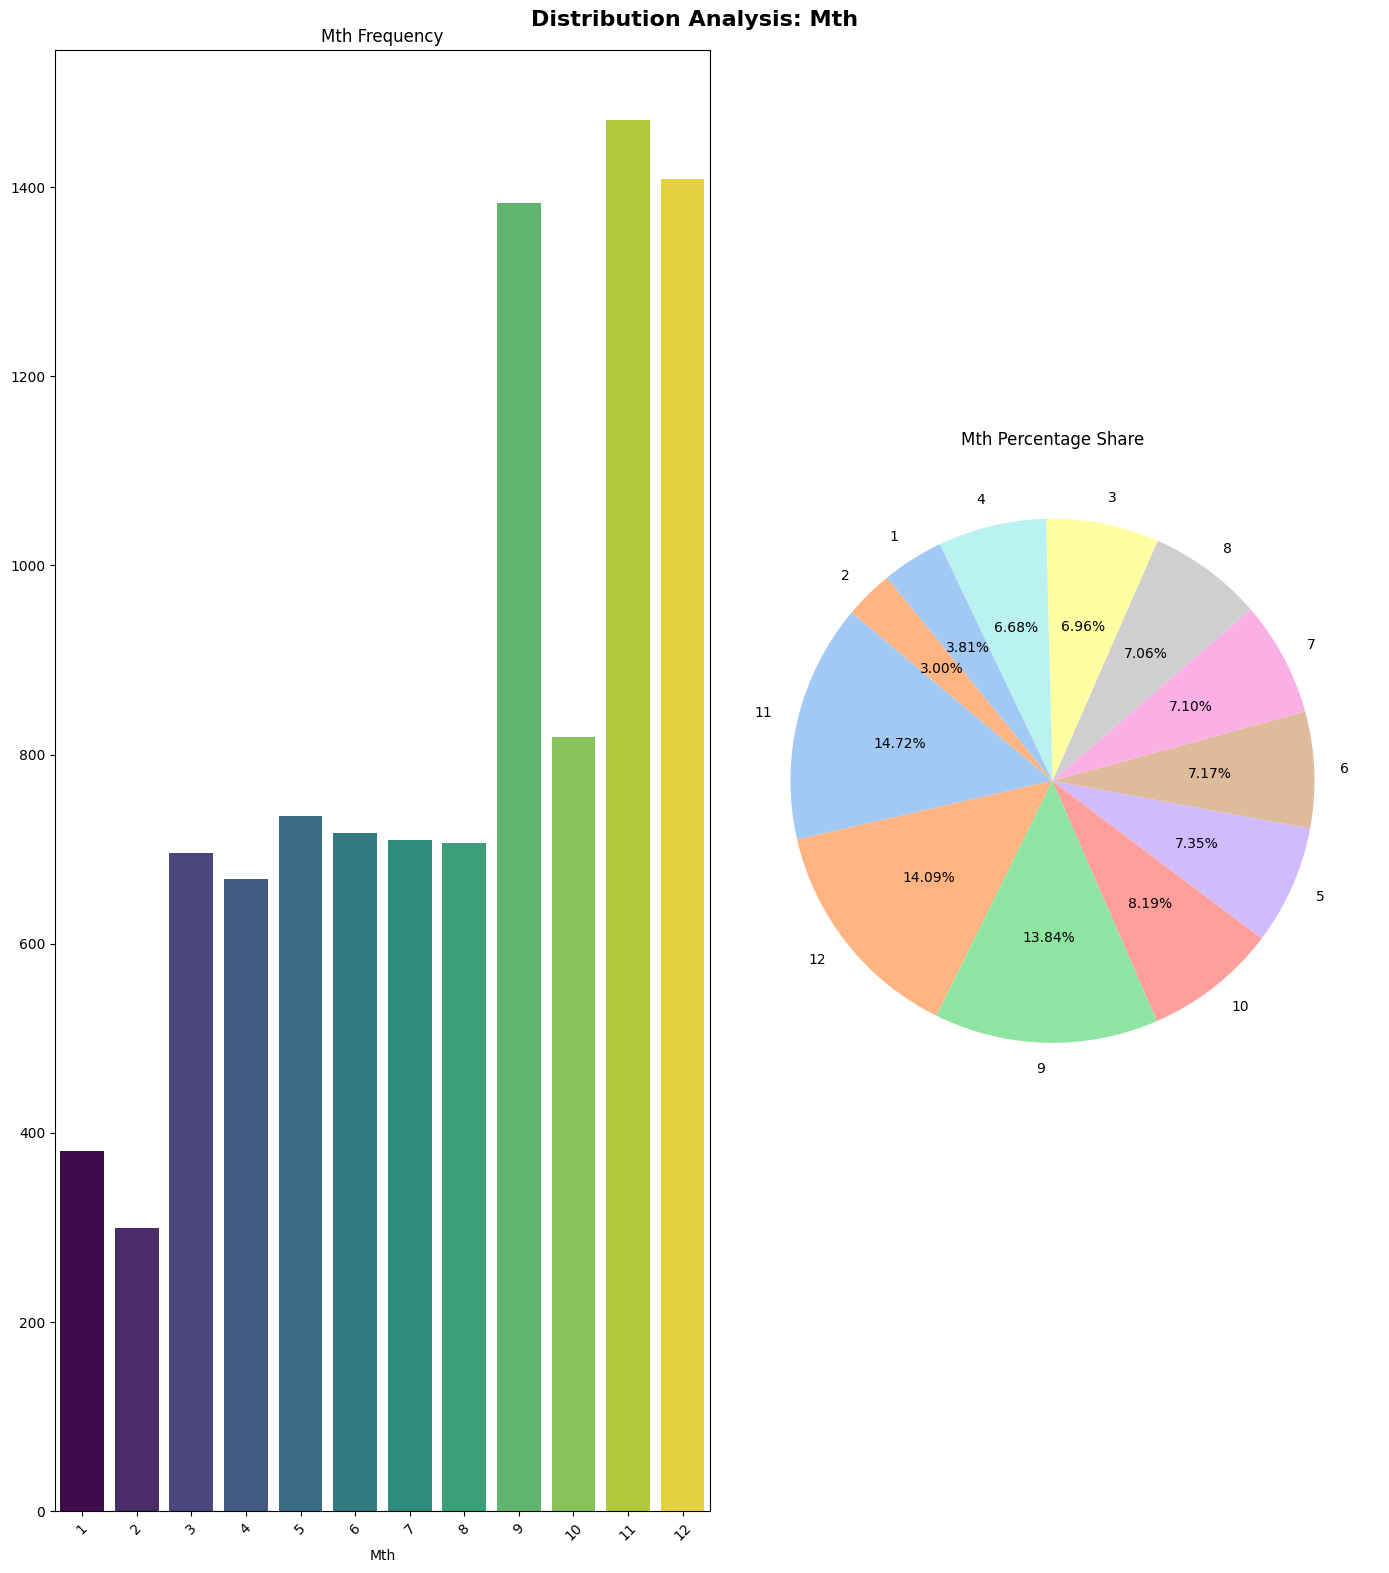

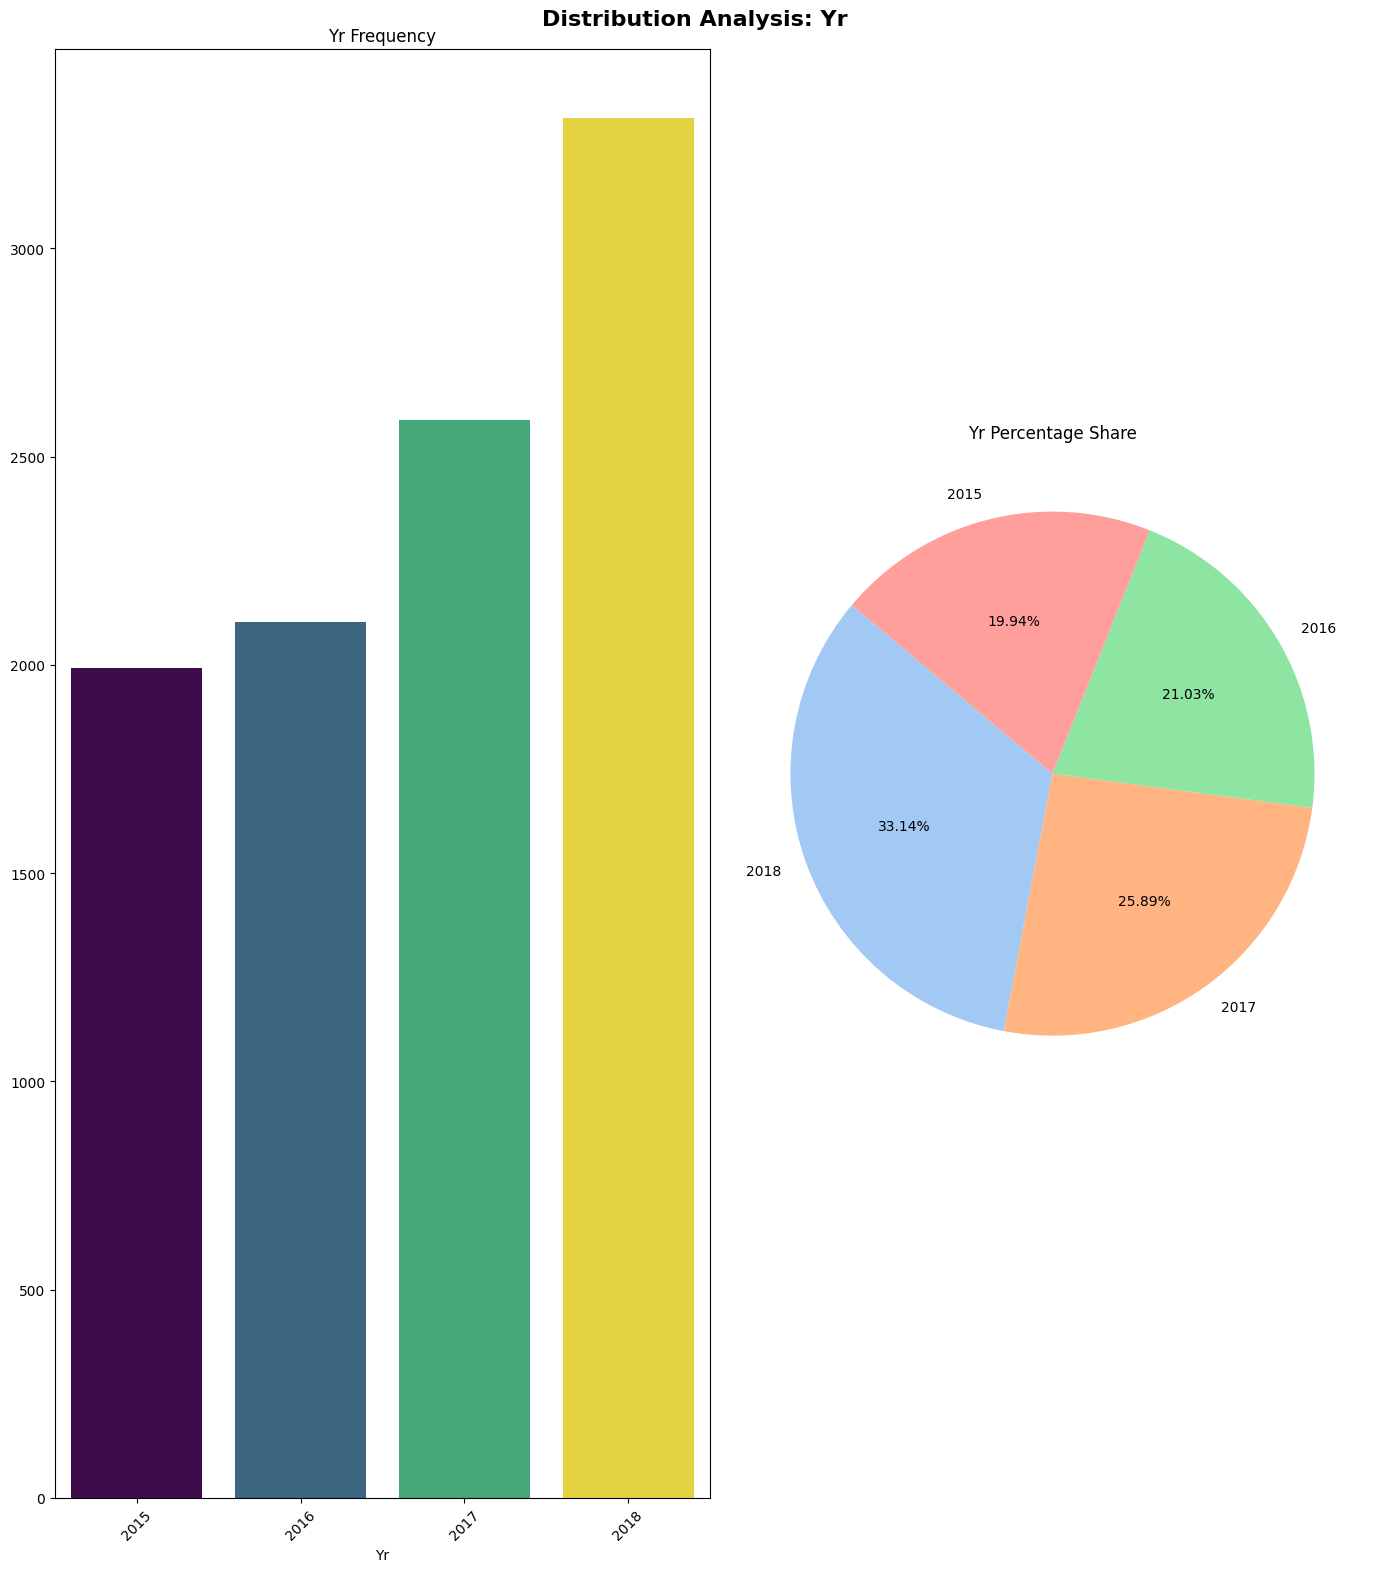

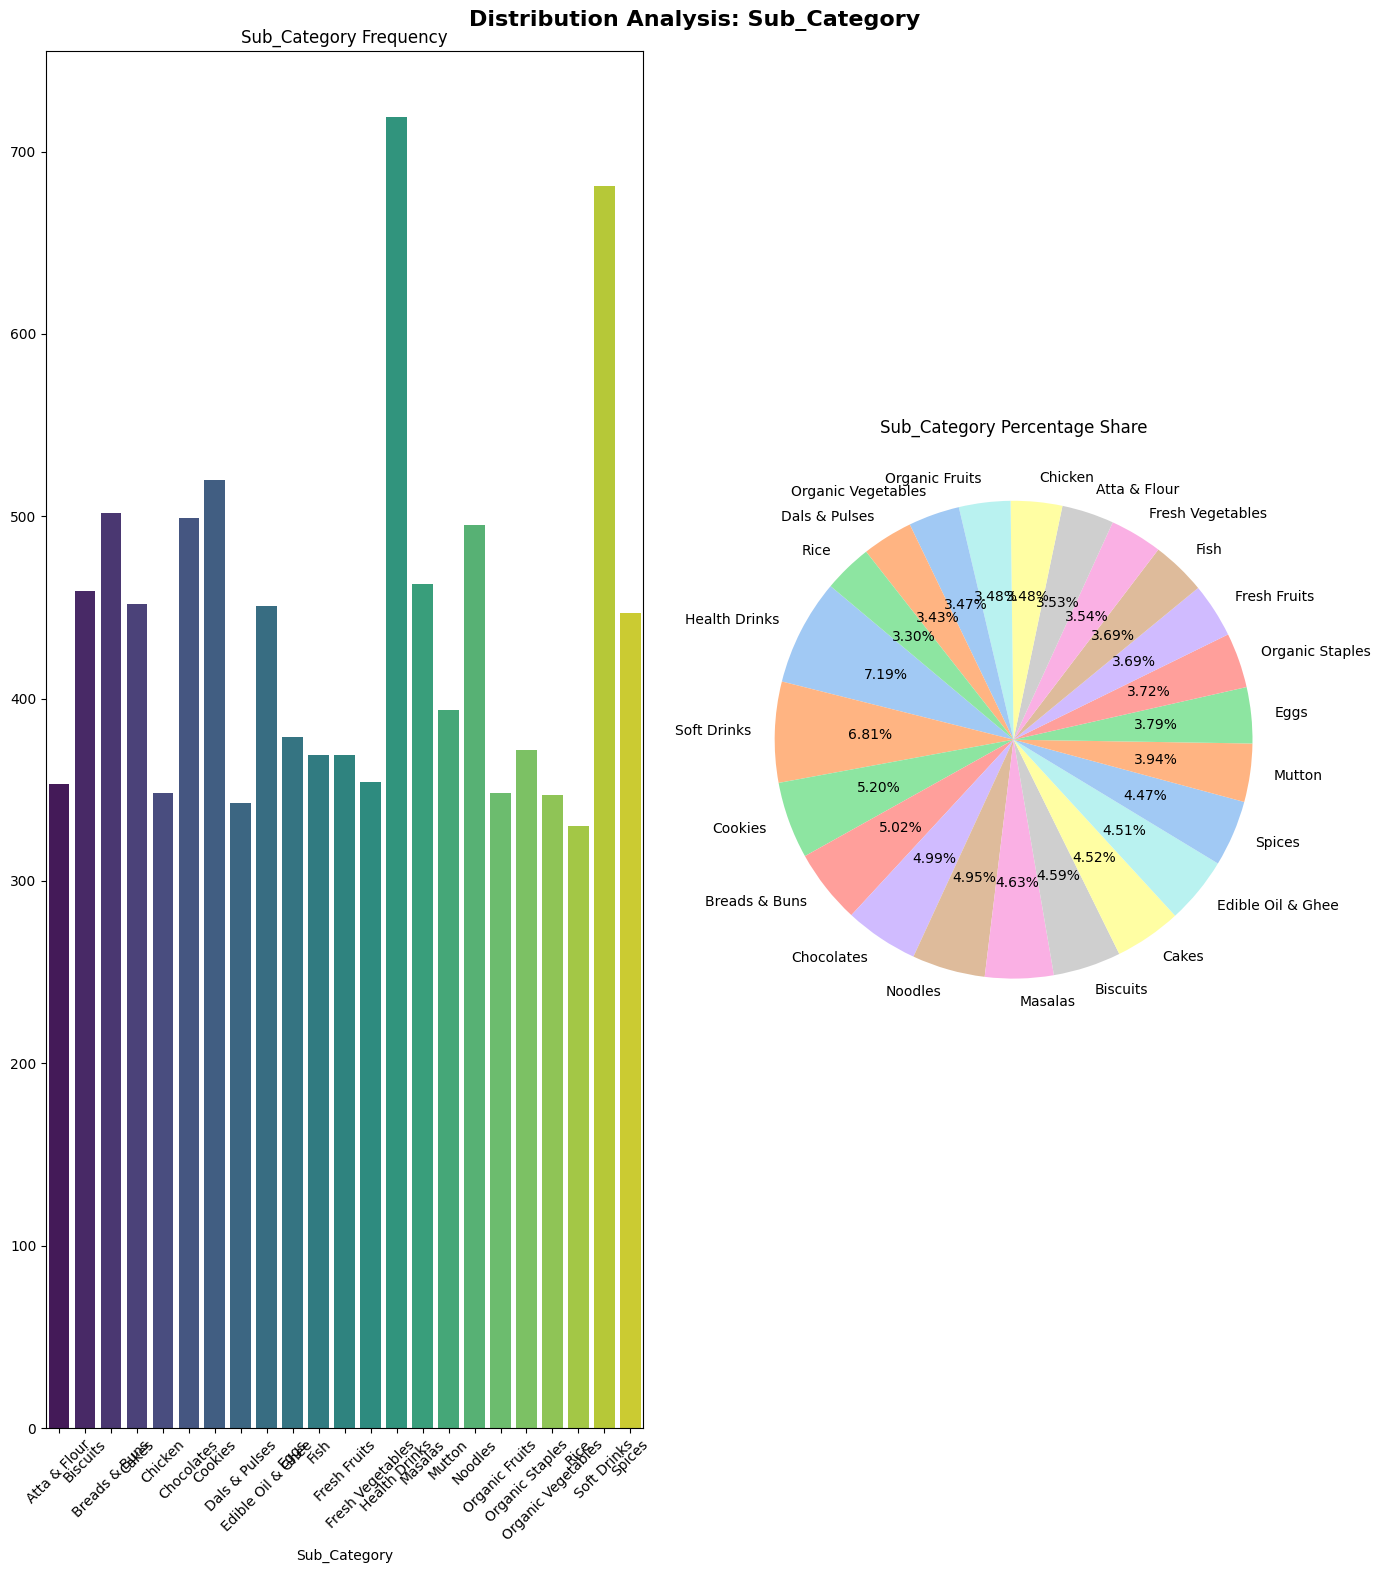

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using a valid style name for modern Matplotlib/Seaborn
plt.style.use('seaborn-v0_8-muted')

cols = ['Dy', 'Mth', 'Yr', 'Sub_Category']

for i in cols:
    fig, ax = plt.subplots(1, 2, figsize=(14, 16))
    fig.suptitle(f'Distribution Analysis: {i}', fontsize=16, fontweight='bold')

    # Bar Plot
    counts = data[i].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette='viridis', hue=counts.index, legend=False)
    ax[0].set_title(f'{i} Frequency')
    ax[0].tick_params(axis='x', rotation=45)

    # Pie Plot
    data[i].value_counts().plot(kind='pie', autopct="%.2f%%", ax=ax[1], colors=sns.color_palette('pastel'), startangle=140)
    ax[1].set_ylabel('')
    ax[1].set_title(f'{i} Percentage Share')

    plt.tight_layout()
    plt.show()

The charts help in understanding how the data is distributed across different categories and make it easier to compare frequencies and proportions visually. Rotation is also added to the axis labels to improve readability. It also help in knowing the percentage of each column in the bar chart

# **BIVARIATE ANALYSIS**

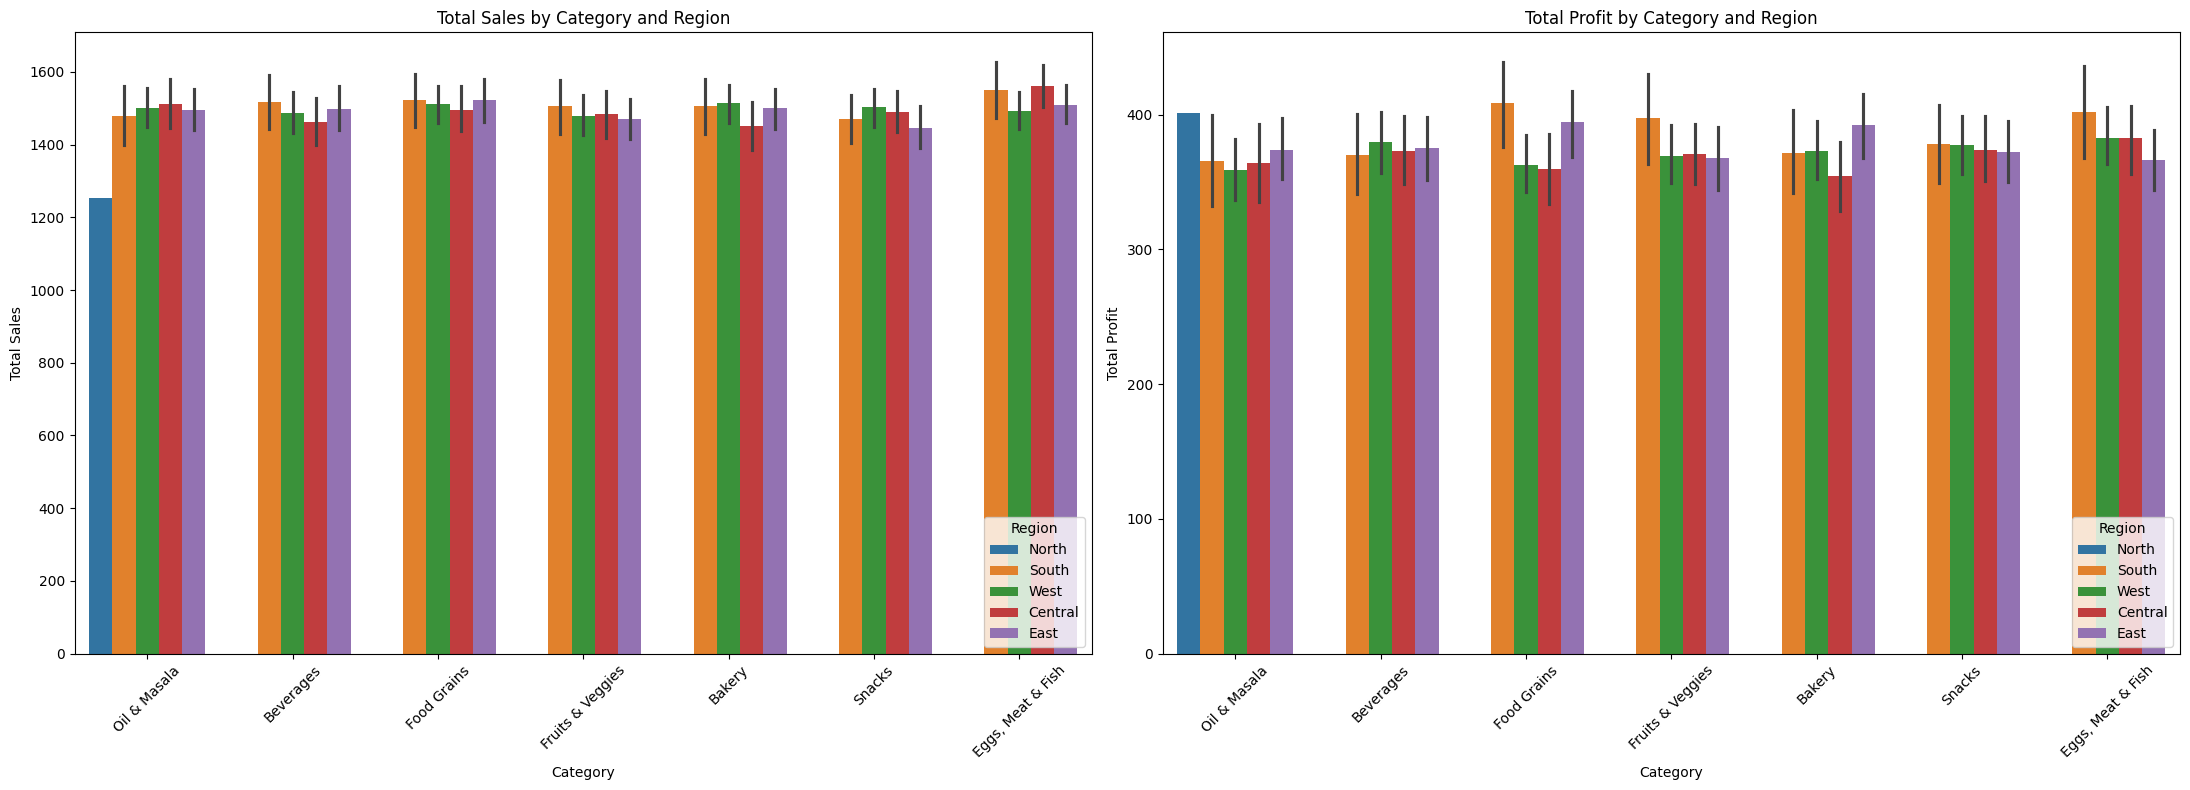

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.barplot(x='Category', y='Sales', hue='Region', data=data, ax=axes[0], palette='tab10')
axes[0].set_title('Total Sales by Category and Region')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Region')

sns.barplot(x='Category', y='Profit', hue='Region', data=data, ax=axes[1], palette='tab10')
axes[1].set_title('Total Profit by Category and Region')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Region')

plt.tight_layout()
plt.show()


The first chart shows the total sales generated by each category in different regions, while the second chart displays the total profit made from each category by region. Different colors are used to represent each region, making the comparison clearer and more visually appealing. (Egg meat & Fish) makes most sales and (food and grains) in south makes profit

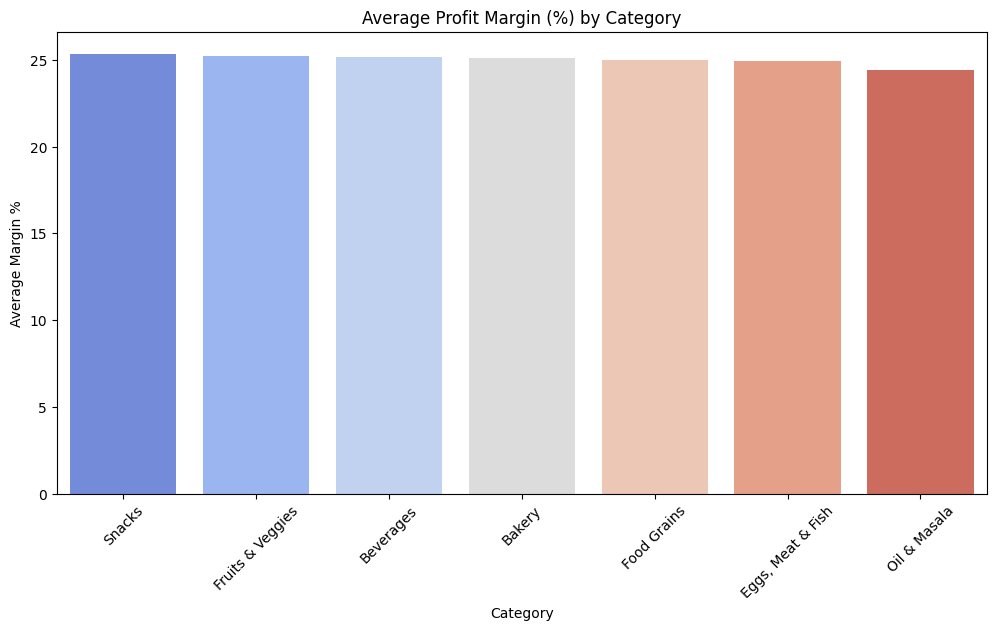

In [26]:
data['Profit_Margin'] = (data['Profit'] / data['Sales']) * 100
category_margin = data.groupby('Category')['Profit_Margin'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Profit_Margin', data=category_margin, palette='coolwarm')
plt.title('Average Profit Margin (%) by Category')
plt.ylabel('Average Margin %')
plt.xticks(rotation=45)
plt.show()

This code is used to calculate and visualize the profit margin percentage for each product category. A new column called Profit_Margin is created by dividing Profit by Sales and multiplying by 100 to get the percentage.And also a bar chart is created to show the average profit margin of each category, making it easy to compare which categories are more profitable relative to their sales. In which Snacks has the highest profit margin and oil and masala has the least

In [27]:
data['Dy'] = data['Dy'].astype(str)
data['Mth'] = data['Mth'].astype(str)

This code is used to change the data type of the Dy and Mth columns to string format. This ensures that the day and month values are treated as text instead of numbers.

<Figure size 1600x2000 with 0 Axes>

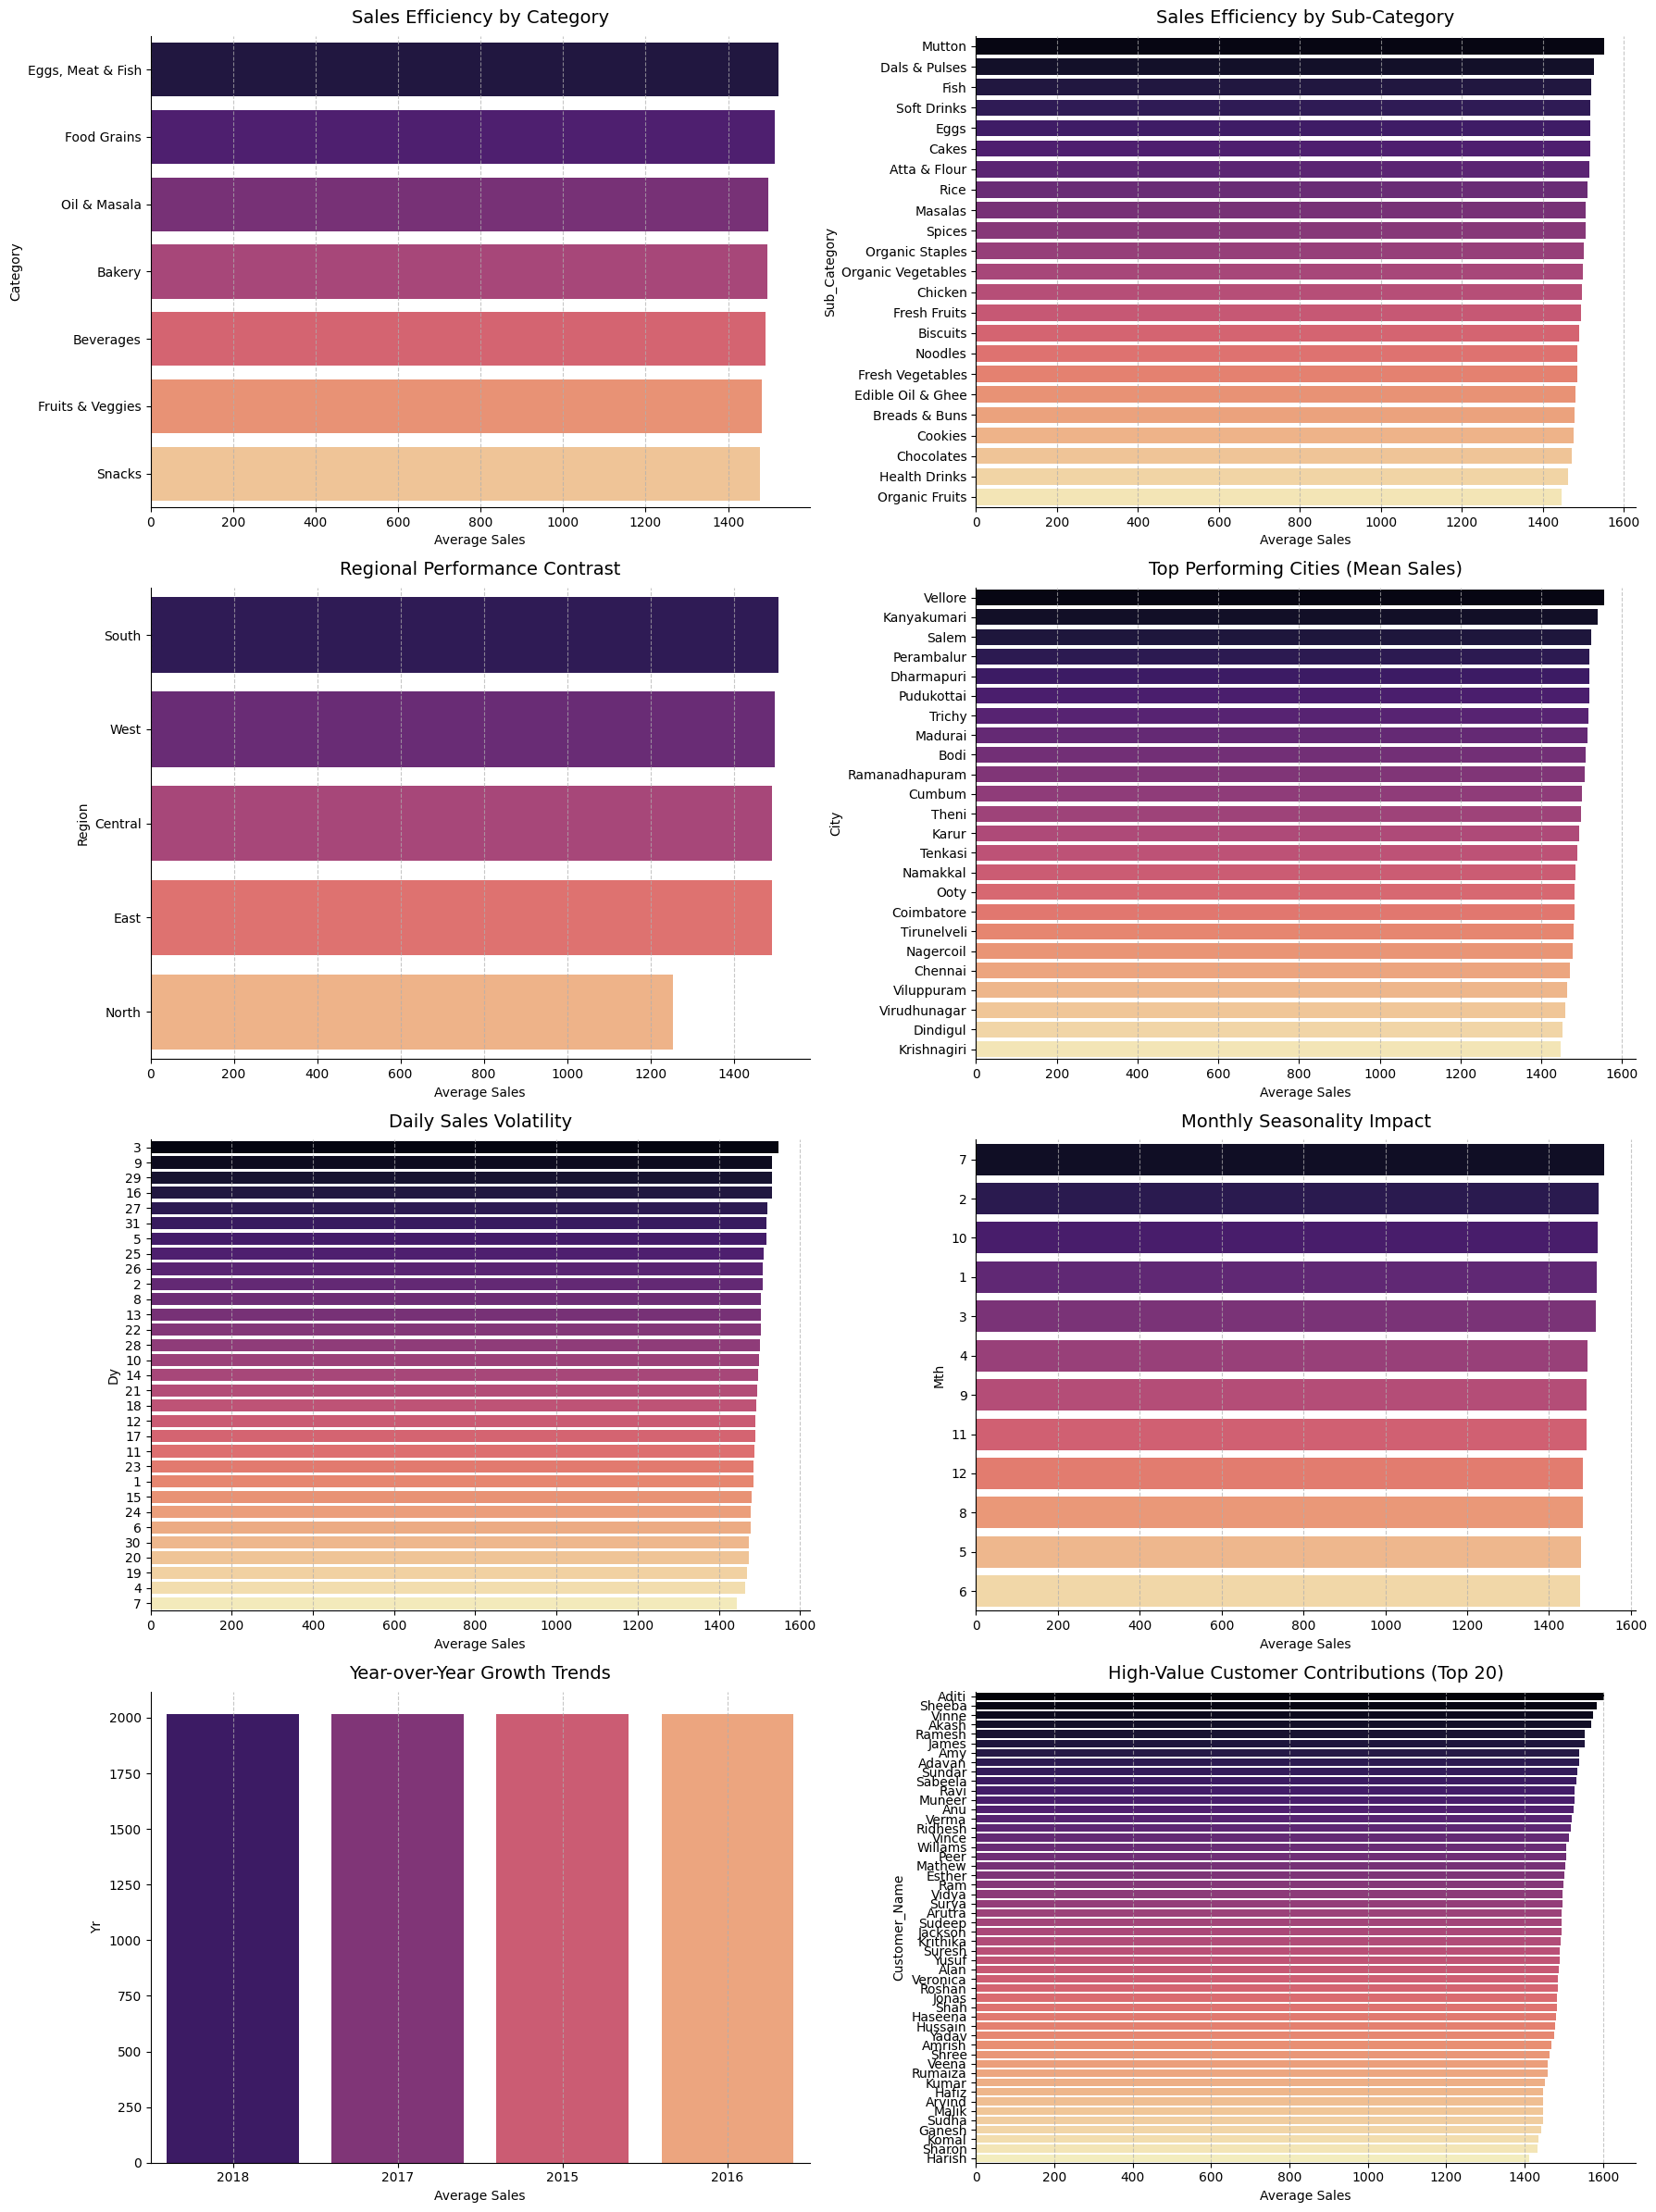

In [28]:
plt.figure(figsize=(16, 20))

# Defining a function for clean, consistent bar plots
def professional_bar(data, group_col, value_col, ax, title):
    order = data.groupby(group_col)[value_col].mean().sort_values(ascending=False).index
    sns.barplot(x=value_col, y=group_col, data=data, ax=ax, order=order, palette='magma', errorbar=None)
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel(f'Average {value_col}')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

fig, axes = plt.subplots(4, 2, figsize=(18, 24))

professional_bar(data, 'Category', 'Sales', axes[0, 0], 'Sales Efficiency by Category')
professional_bar(data, 'Sub_Category', 'Sales', axes[0, 1], 'Sales Efficiency by Sub-Category')
professional_bar(data, 'Region', 'Sales', axes[1, 0], 'Regional Performance Contrast')
professional_bar(data, 'City', 'Sales', axes[1, 1], 'Top Performing Cities (Mean Sales)')
professional_bar(data, 'Dy', 'Sales', axes[2, 0], 'Daily Sales Volatility')
professional_bar(data, 'Mth', 'Sales', axes[2, 1], 'Monthly Seasonality Impact')
professional_bar(data, 'Yr', 'Sales', axes[3, 0], 'Year-over-Year Growth Trends')
professional_bar(data, 'Customer_Name', 'Sales', axes[3, 1], 'High-Value Customer Contributions (Top 20)')

plt.tight_layout()
sns.despine()
plt.show()



<Figure size 1600x2000 with 0 Axes>

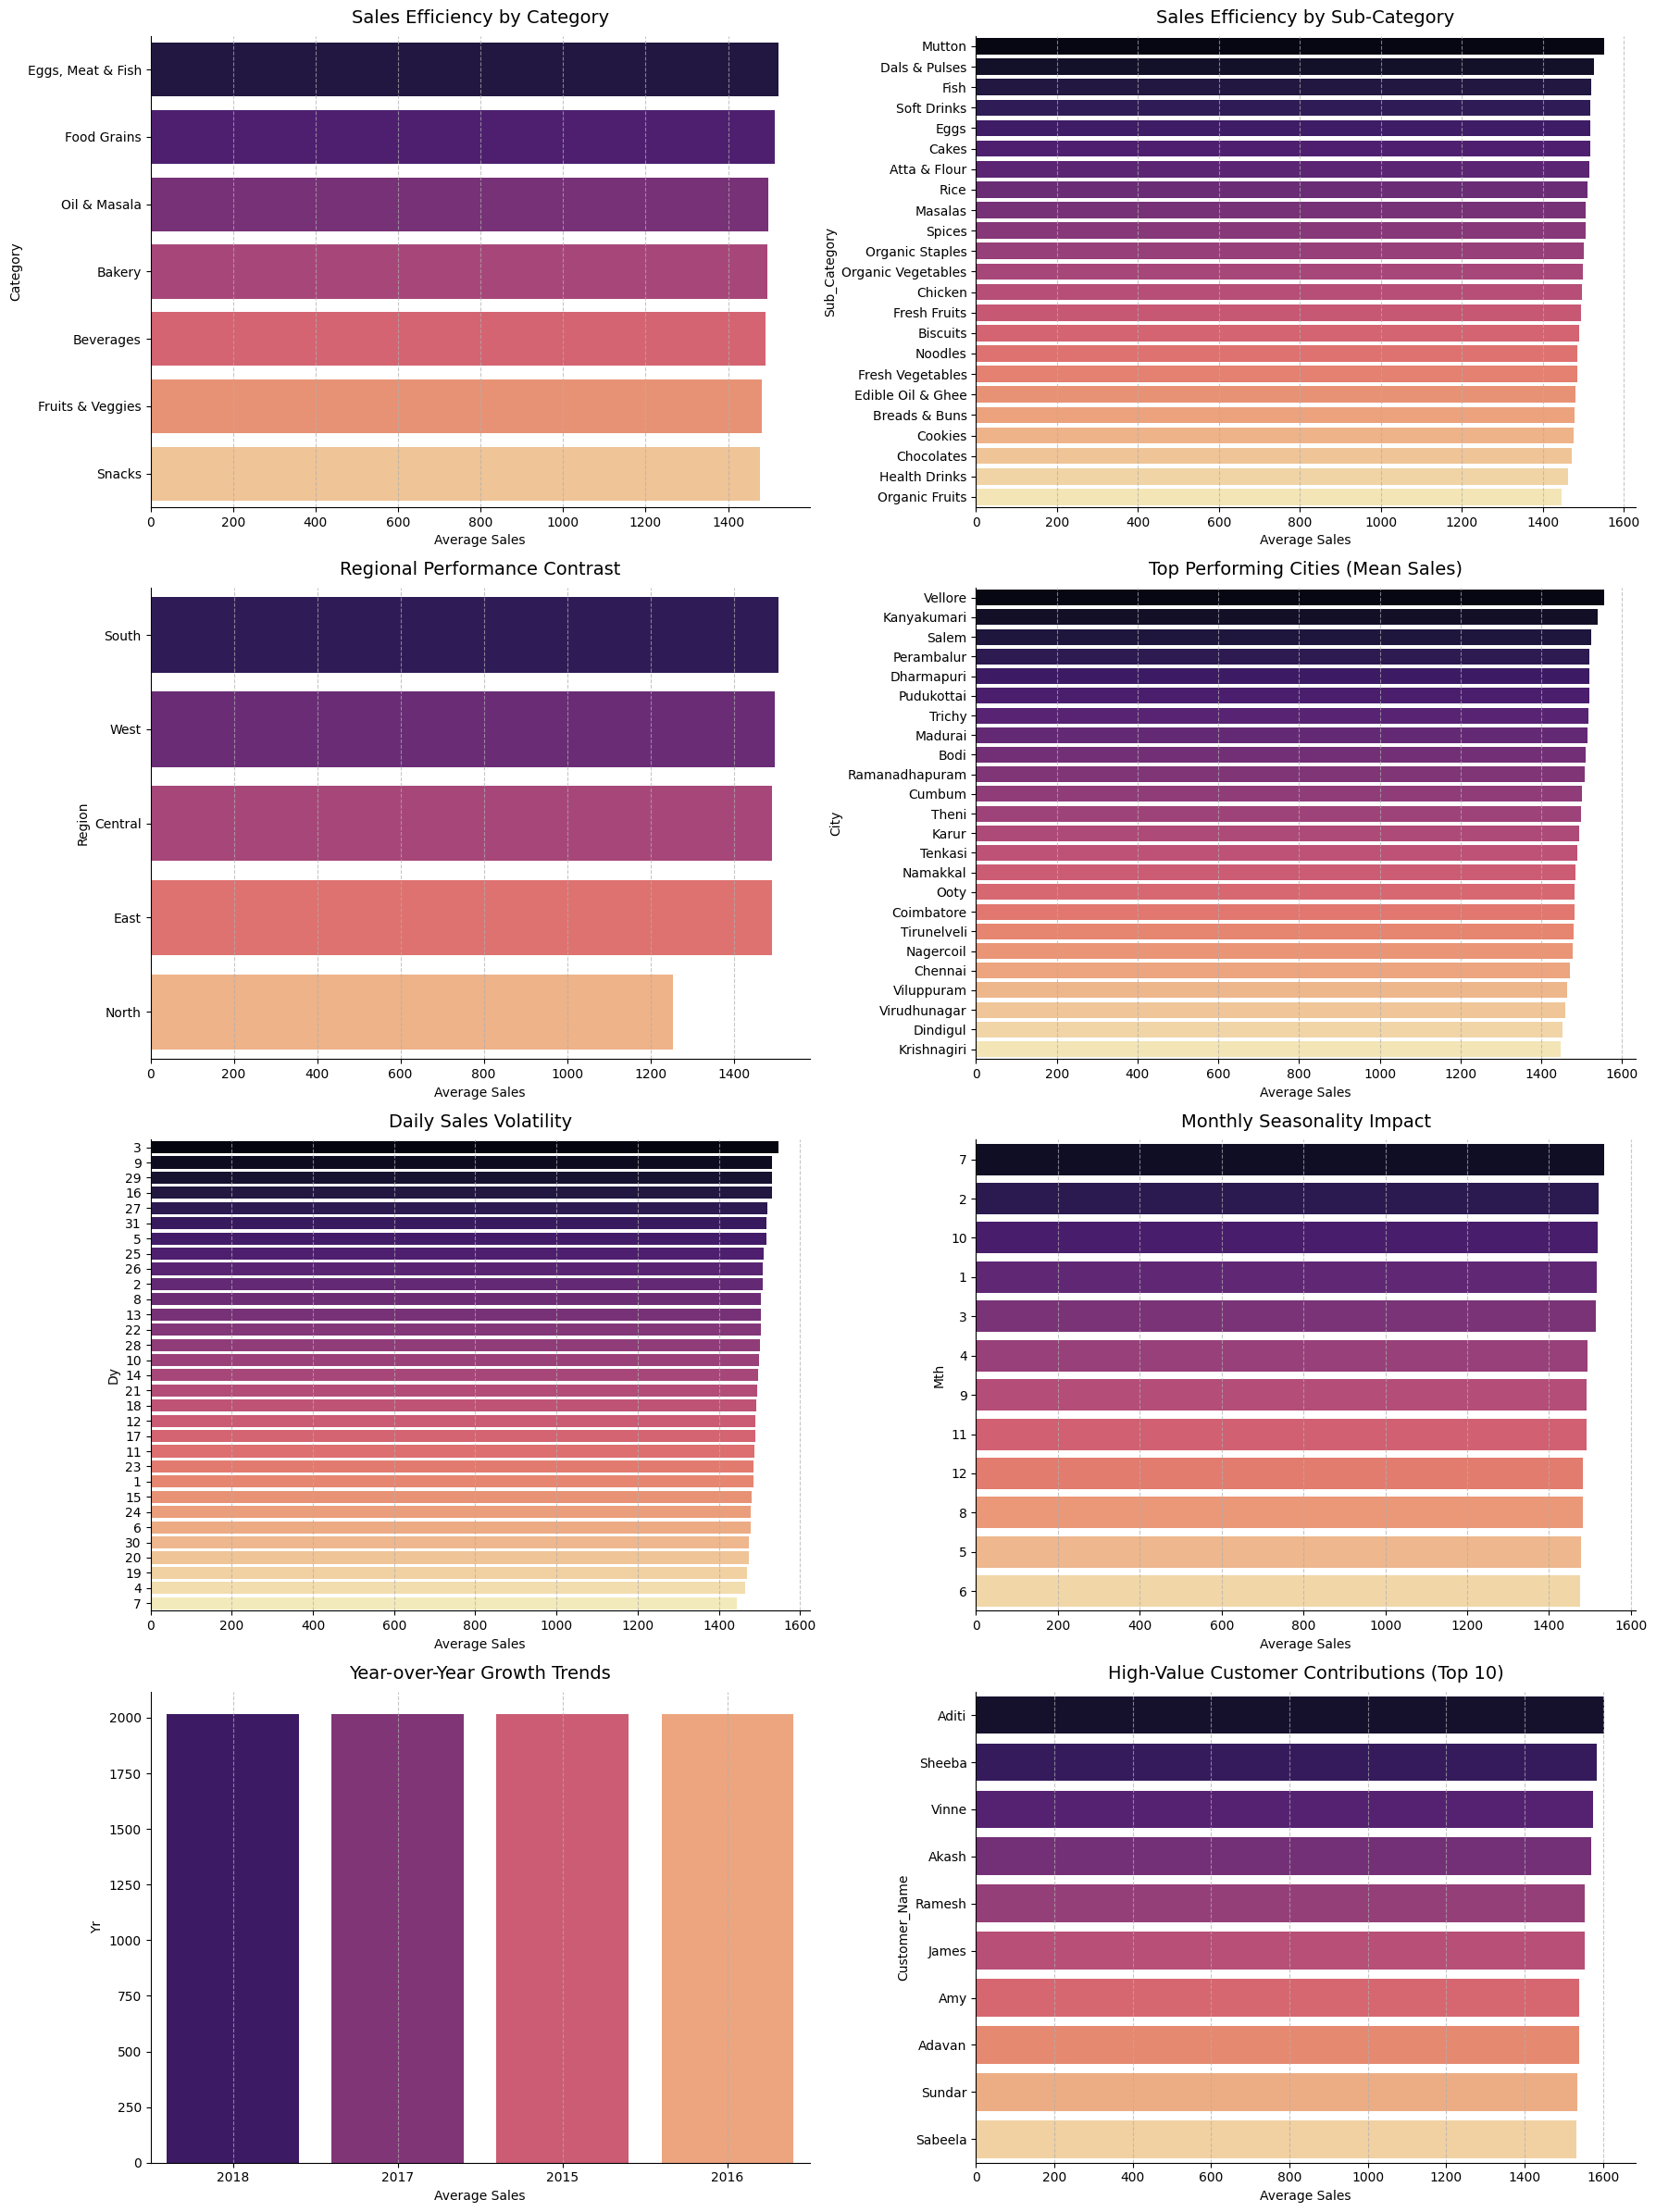

In [29]:
plt.figure(figsize=(16, 20))

# Defining a function for clean, consistent bar plots
def professional_bar(data, group_col, value_col, ax, title, top_n=None):
    grouped = data.groupby(group_col)[value_col].mean().sort_values(ascending=False)
    # Keep only top N if specified
    if top_n:
        grouped = grouped.head(top_n)
    order = grouped.index

    sns.barplot(
        x=value_col,
        y=group_col,
        data=data[data[group_col].isin(order)],
        ax=ax,
        order=order,
        palette='magma',
        errorbar=None
    )

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel(f'Average {value_col}')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

fig, axes = plt.subplots(4, 2, figsize=(18, 24))

professional_bar(data, 'Category', 'Sales', axes[0, 0], 'Sales Efficiency by Category')
professional_bar(data, 'Sub_Category', 'Sales', axes[0, 1], 'Sales Efficiency by Sub-Category')
professional_bar(data, 'Region', 'Sales', axes[1, 0], 'Regional Performance Contrast')
professional_bar(data, 'City', 'Sales', axes[1, 1], 'Top Performing Cities (Mean Sales)')
professional_bar(data, 'Dy', 'Sales', axes[2, 0], 'Daily Sales Volatility')
professional_bar(data, 'Mth', 'Sales', axes[2, 1], 'Monthly Seasonality Impact')
professional_bar(data, 'Yr', 'Sales', axes[3, 0], 'Year-over-Year Growth Trends')

# Top 10 customers only
professional_bar(
    data,
    'Customer_Name',
    'Sales',
    axes[3, 1],
    'High-Value Customer Contributions (Top 10)',
    top_n=10
)

plt.tight_layout()
sns.despine()
plt.show()

The charts help reveal important business insights such as top-performing categories, sales trends over time, regional performance differences, and the most valuable customers contributing to sales growth.
In sales efficiency and category Egg meat & fish generate most revenue while Snacks generate least. In sales by Sub category mutton generate most revenue while organic fruit generate least. In regional perfomance contrast south has the highest while North has the least. In top performing cities vellore has the highest sales while Krishnagiri has the low sales. In Daily sales volatility 3rd day generate the highest sales while 7th generate the least. Monthly Seasonality impact August(7)  has the highest while July(6) has the lowest. In the list of top(10) sales Aditi purchase most product while Sabeela purchase least

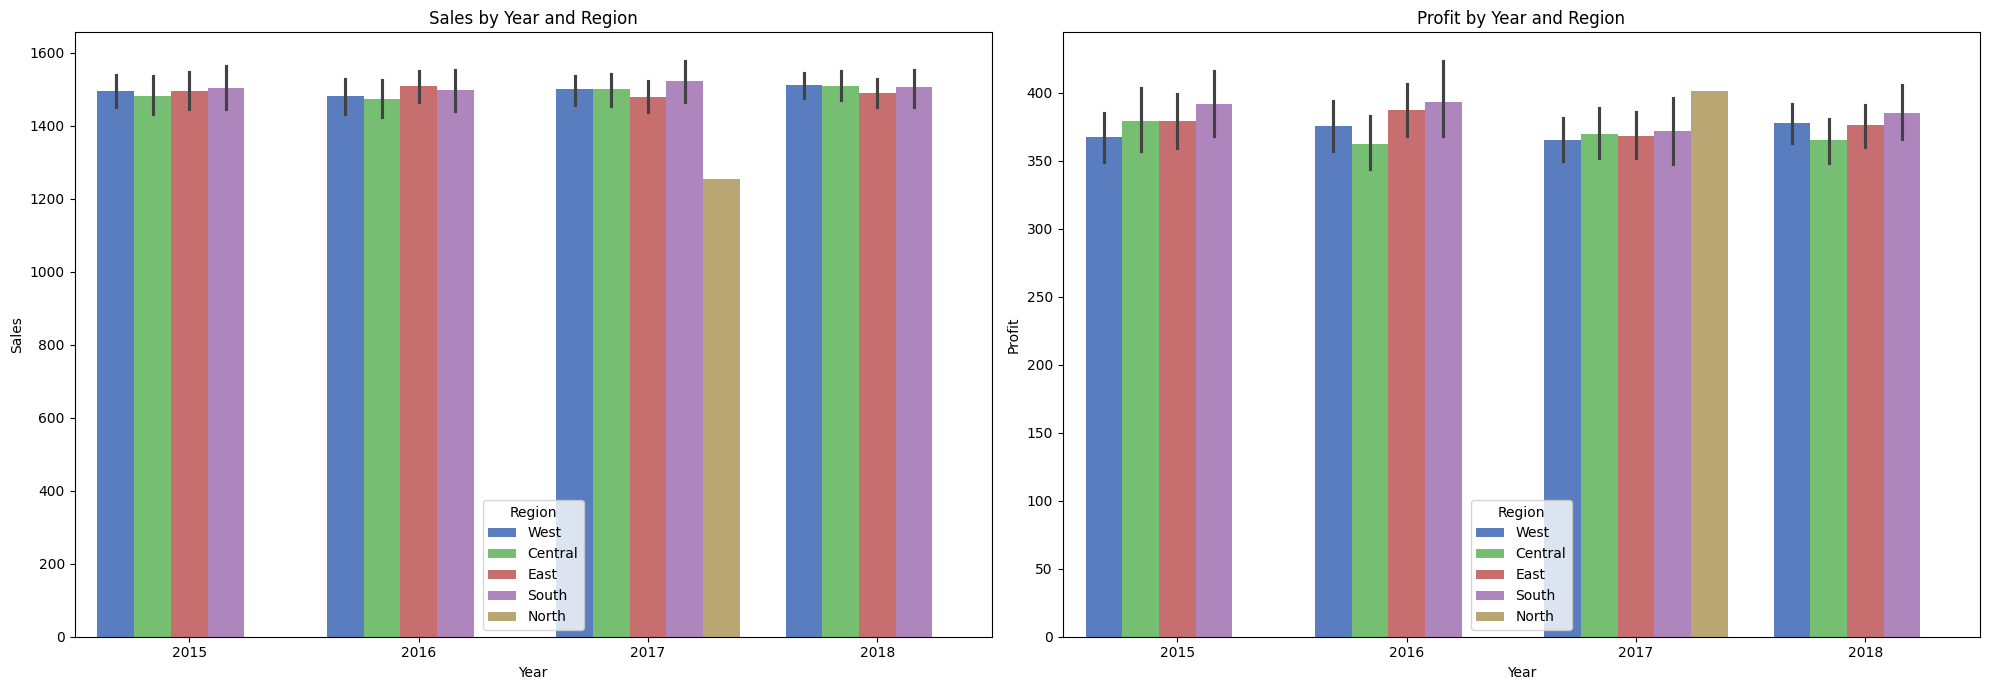

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Sales by Year and Region
sns.barplot(x='Yr', y='Sales', hue='Region', data=data, ax=axes[0])
axes[0].set_title('Sales by Year and Region')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Sales')

# Profit by Year and Region
sns.barplot(x='Yr', y='Profit', hue='Region', data=data, ax=axes[1])
axes[1].set_title('Profit by Year and Region')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

The generated plots provide a clear comparison of 'Total Sales by Year and Region' and 'Total Profit by Year and Region'. They show how different regions contribute to sales and profit across the years, allowing for visual identification of top-performing regions and potential trends in both sales volume and profitability.

# **MULTIVARIATE ANALYSIS**

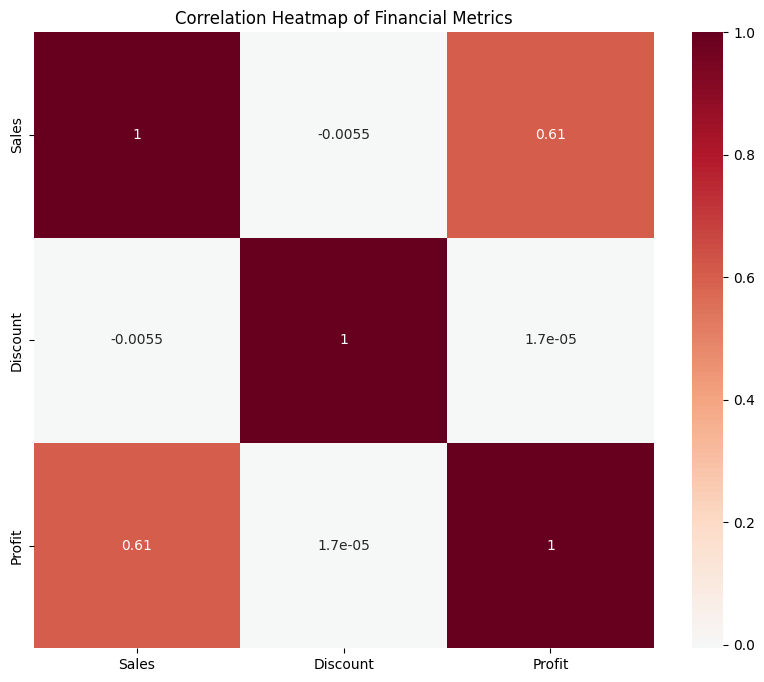

In [31]:
plt.figure(figsize=(10, 8))
correlation_matrix = data[['Sales', 'Discount', 'Profit']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Financial Metrics')
plt.show()

In Sales and Profit (0.61) there is a strong positive correlation between Sales and Profit, this means that as sales increase, profit also tends to increase significantly. Sales and Discount (-0.0055) the correlation between Sales and Discount is very close to zero, this suggests that discounts do not strongly influence sales positively or negatively.Profit and Discount (0.000017) similar to sales and discount, the correlation between Profit and Discount is also extremely close to zero, this implies that discounts have a negligible linear impact on profit. And lastly The correlation between sales discount and profit(1) means that as one variable increases, the other variable also increases in the same direction proportionally.

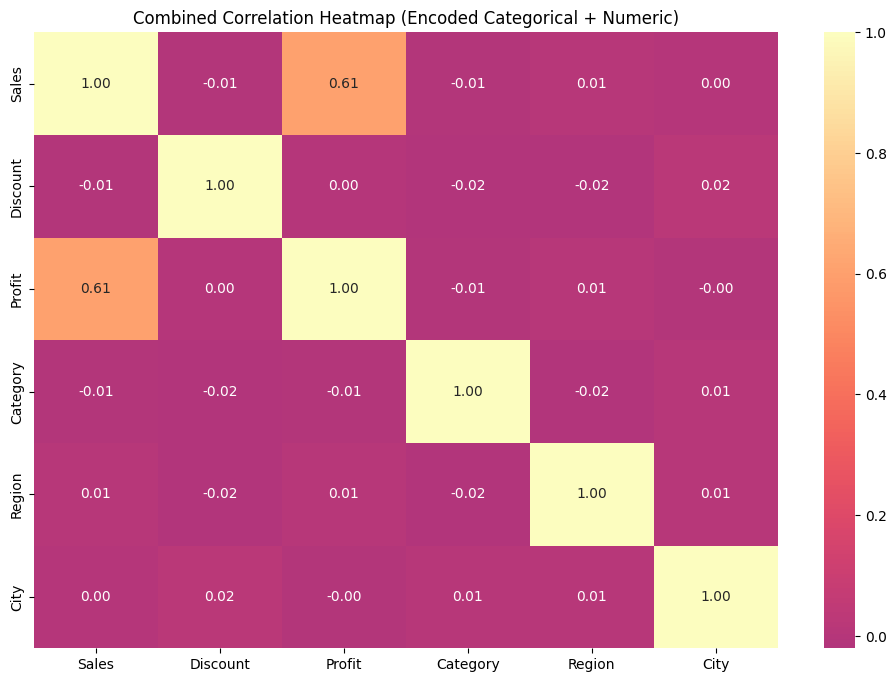

In [32]:
from sklearn.preprocessing import LabelEncoder

# Creating a copy for correlation analysis
corr_data = data[['Sales', 'Discount', 'Profit', 'Category', 'Region', 'City']].copy()

# Encode categorical columns
le = LabelEncoder()
for col in ['Category', 'Region', 'City']:
    corr_data[col] = le.fit_transform(corr_data[col])

# Plotting the expanded heatmap
plt.figure(figsize=(12, 8))
combined_corr = corr_data.corr()
sns.heatmap(combined_corr, annot=True, cmap='magma', center=0, fmt='.2f')
plt.title('Combined Correlation Heatmap (Encoded Categorical + Numeric)')
plt.show()

This cell analyze the relationships between both numerical and categorical variables in the dataset. Since correlation only works with numbers, categorical columns like Category, Region, and City are first converted into numeric values using Label Encoding.

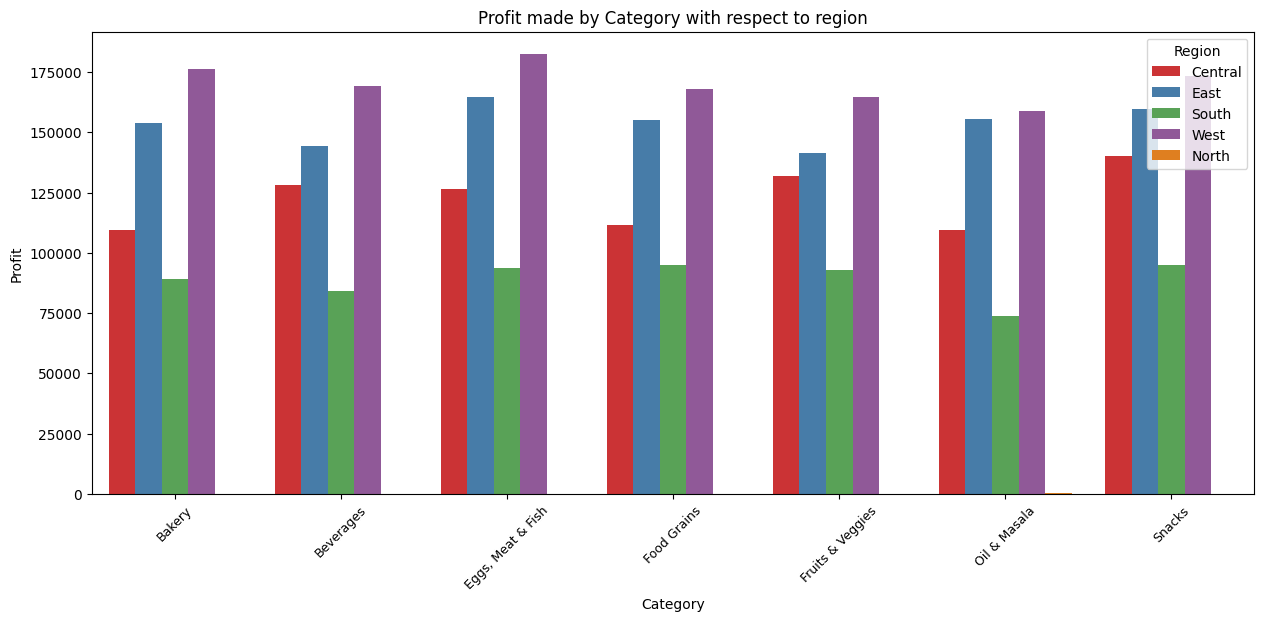

In [33]:
data_trans = data.groupby(['Category', 'Region'])[['Profit']].sum().reset_index()

plt.figure(figsize=(15,6))
sns.barplot(x=data_trans['Category'], y=data_trans['Profit'], hue=data_trans['Region'], ci=None, palette="Set1")
plt.title("Profit made by Category with respect to region")
plt.ylabel("Profit")
plt.xticks(rotation=45, fontsize = 9)
plt.show()

the visualization helps in understanding which categories perform best in each region and how profit is distributed across locations.
In the Category mostly Region(West)  generate highest profit While (South) generate least profit

In [34]:
import plotly.express as px

fig = px.sunburst(data,
                  path=['Category', 'Sub_Category', 'Region'],
                  values='Sales',
                  color='Profit',
                  color_continuous_scale='RdYlGn',
                  title='Hierarchical Sales & Profit Distribution')
fig.update_layout(width=800, height=800)
fig.show()

This cell create a sunburst chart that shows how Sales and Profit are distributed across Category, Sub-Category, and Region in a hierarchical way.Each circle represents a level of the data, starting from Category and breaking down into Sub-Category and Region.

Egg, Meat, and Fish generate the highest profit among the product categories and fish generate the largest profit in the sub category follow by Eggs, Mutton and Chickens is the lowest

Beverages is the second highest profit among the category and Soft drinks is the largest profit in the sub category and Health drinks is the least

Snacks is the third highest profit among the product category and Noodles generates largest profit in the sub category follow by cookies and chocolate is the lowest

Food grains  is the fourth in the category that generate highest profit and organic staples generates largest profit in the sub category follow by Rice, Dals& Pulsed and Atta & Flour is the least

Fruit and veggies is fifth in the category circle that generate profit and organic fruits is the largest profit in the sub category follow by Organic vegetables, fresh vegetables and Fresh fruit is the least

Bakery is the sixth in the category that generates profit and Bread& Buns generate the highest profit in the sub category follow by Biscuits and cakes is the least

Oil and Masala is the last in the category that generate least profit and Edible oil& ghee generates the highest in the sub category follow by Masala and Spices is the least